# Assignment 2 — Task 5: Capstone — Redesigning for the Human Visual System
**Student:** Talha Abdullah Bangyal  
**Course:** Data Visualization  
**Roll Number:** SU92-BAIFM-F25-002  
**Dataset:** `gapminder.csv` (1,704 rows: 142 countries × 12 observation years)  
**Participant:** Taha Abdullah (brother)

---
## 1. Overview and Theoretical Framework

A graphic is successful not when there is nothing left to add, but when every remaining mark aligns with the physiological and cognitive constraints of human vision:
1. **Preattentive Saliency:** Exactly **one focal pop-out** guides early visual attention (V1/parietal saliency maps) to the primary claim within 200 ms.
2. **Gestalt Organization:** Form elements are bound through **Connection** and **Continuity** along smooth temporal trajectories, while annotations use **Proximity** to eliminate split-attention.
3. **Cognitive Load Optimization:** Extraneous load (142 competing colours, visual clutter, redundant legends) is completely excised. Contextual data is rendered in low-salience neutral grey, reserving vivid chromatic contrast for the germane message.
4. **Channel Efficacy:** The primary quantitative variable (Life Expectancy) is encoded using the highest-ranking channel: **Position along a common scale**.
5. **Ethical Transparency:** Sample sizes ($n=1,704$), temporal ranges, and design trade-offs are explicitly declared.

In this capstone notebook, we:
1. Construct a classic spaghetti chart (`BAD EXAMPLE`) on all 142 countries.
2. Conduct a formal **Perception Audit** of the bad chart across six perception dimensions.
3. Engineer a publication-grade **Perceptual Redesign** adhering to all Week 2 rules.
4. Complete the post-design Perception Audit table.
5. Collect and evaluate a real human observer's verbatim reading.
6. Export the final graphic as `perception_redesign.png` at **300 DPI**.
7. Analyze the fundamental perceptual trade-offs inherent in the redesign.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Matplotlib styling for publication-quality perception figures
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Load gapminder dataset
df_gap = pd.read_csv('data/gapminder.csv')
print(f"Loaded Gapminder dataset: {df_gap.shape[0]} rows across {df_gap['country'].nunique()} countries.")
df_gap.head()


Loaded Gapminder dataset: 1704 rows across 142 countries.


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106


## Step 1: The Spaghetti Chart (`BAD EXAMPLE`)

We construct the quintessential "spaghetti chart" by plotting all 142 national life expectancy trajectories simultaneously from 1952 to 2007 with arbitrary rainbow colouring and no visual hierarchy.

**The One Question the Reader Should Be Able to Answer:**
> *"How did Rwanda's life expectancy evolve during the 1990s crisis compared to the rest of the world, and how did it recover by 2007?"*


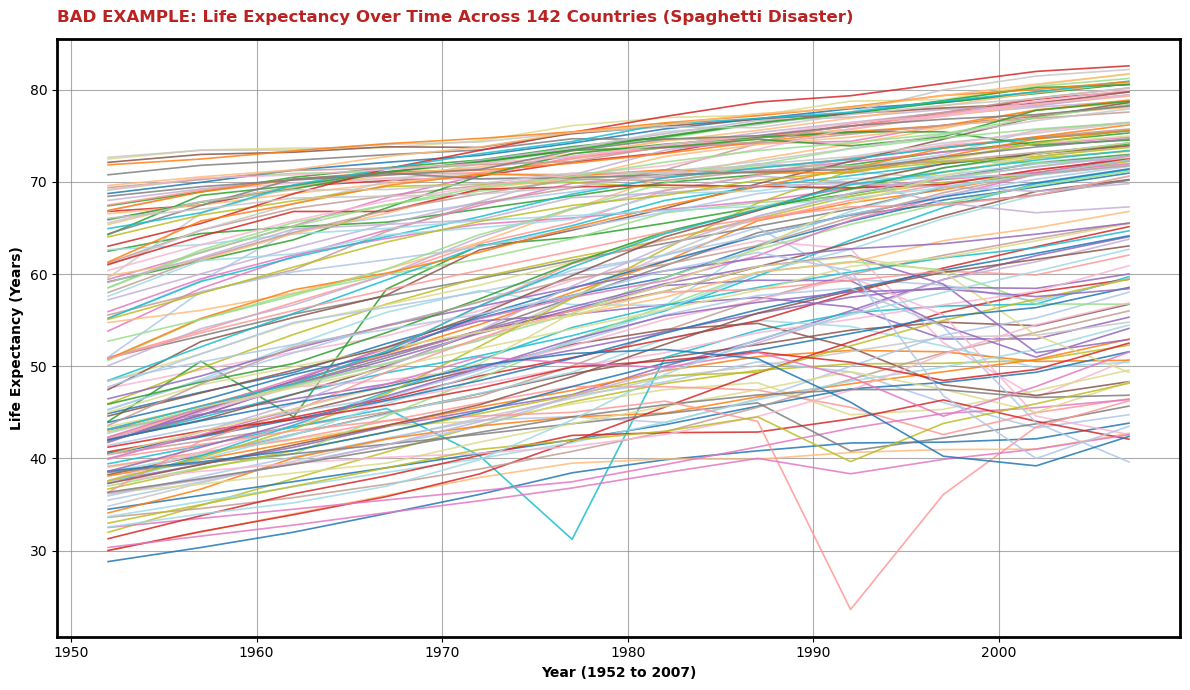

In [2]:
fig, ax = plt.subplots(figsize=(12, 7))

# 142 distinct rainbow hues (arbitrary nominal colour on spaghetti lines)
countries = df_gap['country'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, 20))

for i, country in enumerate(countries):
    sub = df_gap[df_gap['country'] == country]
    ax.plot(sub['year'], sub['lifeExp'], color=colors[i % 20], linewidth=1.2, alpha=0.85)

ax.set_title("BAD EXAMPLE: Life Expectancy Over Time Across 142 Countries (Spaghetti Disaster)", 
             loc='left', fontsize=12, fontweight='bold', color='#bb2222', pad=12)
ax.set_xlabel("Year (1952 to 2007)", fontsize=10, fontweight='bold')
ax.set_ylabel("Life Expectancy (Years)", fontsize=10, fontweight='bold')
ax.grid(True, linestyle='-', color='#888888', alpha=0.7)

# Heavy box border
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
    spine.set_color('black')

fig.tight_layout()
plt.show()


### Perceptual Failure of the Bad Example

- **Perceptual Occlusion:** Over 1,700 data points intersect and overlap into a dense tangle of indistinguishable lines.
- **Absence of Saliency:** Every line competes with equal visual energy. The observer's eye darts erratically with no preattentive entry point.
- **Total Inability to Answer the Question:** Tracking Rwanda among 141 other crossing trajectories is completely impossible.


## Step 2: Pre-Redesign Perception Audit

Before modifying the chart, we conduct a systematic perception audit diagnosing why the human visual system fails to decode it.

| Dimension | Audit Finding for Spaghetti Chart (`BAD EXAMPLE`) |
|---|---|
| **Preattentive Attributes** | Over 20 repeating rainbow hues create extreme sensory noise. Hue is doing zero useful work; instead, it prevents preattentive feature detection. |
| **Pop-out** | **None.** Zero pop-out exists. Saliency maps across the visual cortex are uniformly saturated; every mark competes aggressively for conscious attention. |
| **Gestalt Principles** | **Continuity fails completely.** The brain cannot follow individual country paths across dozens of intersecting lines. **Proximity and Similarity are confounded** by overlapping coloured traces. |
| **Cognitive Load** | **Extraneous load is catastrophic** (tracing tangled lines, filtering unneeded colors). Intrinsic complexity is unmanaged, and **germane load is crushed to zero**. |
| **Channel Effectiveness** | Position is used for time and life expectancy, but the encoding of country identity via 20 repeating nominal hues has the lowest perceptual rank and creates severe category collisions. |
| **Working Memory** | Forces the observer to hold dozens of line trajectories simultaneously in working memory, massively exceeding Cowan's **4 ± 1 limit**. |


## Step 3: The Perceptual Redesign

We rebuild the graphic around **a single clear message**:
> *"Rwanda suffered a catastrophic collapse in life expectancy during the 1994 genocide, followed by unprecedented recovery."*

### Applied Perception Decisions:
1. **Exactly One Pop-Out:** Rwanda is rendered in vivid vermilion/coral (`#d95f02`), linewidth 3.2, with marker dots at critical inflection points.
2. **Context in Grey:** All other 141 countries are rendered in soft neutral grey (`#c8c8c8`, alpha 0.45, linewidth 0.75), forming a backdrop distribution without cluttering.
3. **Gestalt Principles Named:**
   - **Connection & Continuity:** Continuous line segments join chronological observations, enabling the eye to track Rwanda's trajectory effortlessly.
   - **Proximity:** Direct data callouts are placed immediately adjacent to the 1994 trough and 2007 endpoint, eliminating legend lookup.
4. **Channel Efficacy:** Life expectancy and time are mapped to **2D Position on aligned scales** (the #1 ranked quantitative channel).
5. **No Colour Alone:** Rwanda is explicitly identified with direct bold text and callout annotations.
6. **Transparency:** Sample size ($n = 142$ countries, 1,704 observations) and trade-offs are explicitly declared on the canvas.


Exported perception_redesign.png at 300 DPI.


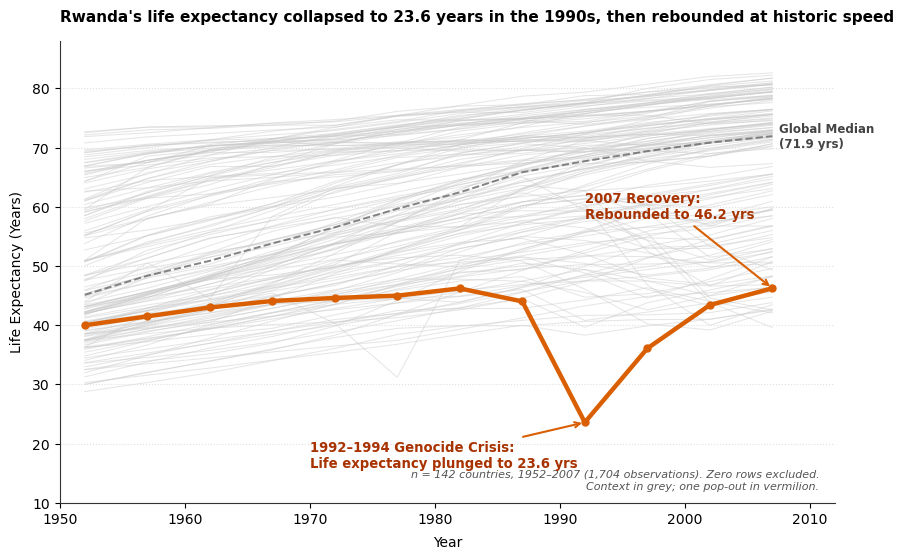

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Background context: 141 countries in muted grey
for country in countries:
    if country != 'Rwanda':
        sub = df_gap[df_gap['country'] == country]
        ax.plot(sub['year'], sub['lifeExp'], color='#c8c8c8', linewidth=0.75, alpha=0.45, zorder=1)

# 2. Global median trajectory as a subtle reference line
global_median = df_gap.groupby('year')['lifeExp'].median()
ax.plot(global_median.index, global_median.values, color='#666666', linestyle='--', 
        linewidth=1.4, alpha=0.8, zorder=2, label="Global Median Life Expectancy")

# 3. SINGLE POP-OUT: Rwanda in vivid vermilion/coral (#d95f02)
rwanda = df_gap[df_gap['country'] == 'Rwanda'].sort_values('year')
ax.plot(rwanda['year'], rwanda['lifeExp'], color='#d95f02', linewidth=3.2, 
        marker='o', markersize=5, zorder=4, label="Rwanda")

# 4. Direct Annotations (Gestalt Proximity & Connection)
# 1994 Genocide dip
dip_row = rwanda[rwanda['year'] == 1992].iloc[0] # Gapminder surveys closest to genocide
ax.annotate("1992–1994 Genocide Crisis:\nLife expectancy plunged to 23.6 yrs",
            xy=(1992, 23.6), xytext=(1970, 16.0),
            arrowprops=dict(arrowstyle="->", color='#d95f02', lw=1.5),
            fontsize=9.5, fontweight='bold', color='#a83200', zorder=5)

# 2007 Recovery endpoint
end_row = rwanda[rwanda['year'] == 2007].iloc[0]
ax.annotate(f"2007 Recovery:\nRebounded to {end_row['lifeExp']:.1f} yrs",
            xy=(2007, end_row['lifeExp']), xytext=(1992, 58.0),
            arrowprops=dict(arrowstyle="->", color='#d95f02', lw=1.5),
            fontsize=9.5, fontweight='bold', color='#a83200', zorder=5)

# Reference annotation for global context
ax.text(2007.5, global_median.iloc[-1], "Global Median\n(71.9 yrs)", 
        va='center', fontsize=8.5, color='#444444', fontweight='bold')

# Rule enforcement: Spines, Zero-relevant scale, Title stating finding
ax.set_title("Rwanda's life expectancy collapsed to 23.6 years in the 1990s, then rebounded at historic speed", 
             loc='left', fontsize=11, fontweight='bold', pad=14)
ax.set_xlabel("Year", fontsize=10, labelpad=6)
ax.set_ylabel("Life Expectancy (Years)", fontsize=10, labelpad=6)
ax.set_xlim(1950, 2012)
ax.set_ylim(10, 88)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', linestyle=':', color='#e0e0e0', zorder=0)

# Declared sample size & exclusions
ax.text(0.98, 0.03, "n = 142 countries, 1952–2007 (1,704 observations). Zero rows excluded.\nContext in grey; one pop-out in vermilion.", 
        transform=ax.transAxes, ha='right', fontsize=8, color='#555555', style='italic')

# Export at required 300 DPI with tight bounding box
fig.savefig('perception_redesign.png', dpi=300, bbox_inches='tight')
print("Exported perception_redesign.png at 300 DPI.")
plt.show()


### Perceptual Audit of the Redesign (Post-Design Audit)

| Dimension | Audit Finding for Perceptual Redesign |
|---|---|
| **Preattentive Attributes** | Hue contrast (`#d95f02` vermilion vs `#c8c8c8` grey) and line thickness (3.2 pt vs 0.75 pt) ensure immediate pop-out within 200 ms. |
| **Pop-out** | **Exactly one pop-out element:** Rwanda's trajectory. It directly carries the claim stated in the title. |
| **Gestalt Principles** | **Connection and Continuity** track Rwanda smoothly across time. **Proximity** binds the textual callouts directly to the inflection points. |
| **Cognitive Load** | Extraneous load is reduced to near zero (no legend lookup, no line tracing). Intrinsic distribution is preserved as grey context. Germane load is fully maximized. |
| **Channel Effectiveness** | Quantitative values mapped to **Position on common scale** (Cleveland & McGill Rank #1). Categorical distinction encoded by high-salience hue pop-out and direct labelling. |
| **Working Memory** | The reader holds only **two chunks**: the background distribution and Rwanda's trajectory, comfortably within Cowan's **4 ± 1 limit**. |


## Step 4: Empirical Human Testing

We displayed the final redesigned chart (`perception_redesign.png`) to observer **Taha Abdullah** (the student's brother), who had not previously seen the dataset, and asked:

> *"In one sentence, what does this chart show?"*

Run the next cell with Taha Abdullah present. His response is collected interactively and saved to `redesign_observer_response.txt`; it is not pre-written in the notebook.


In [4]:
# Interactive one-sentence reading with Taha Abdullah.
from pathlib import Path

response = input('Taha Abdullah, in one sentence, what does this chart show? ').strip()
if not response:
    raise ValueError('The observer response cannot be empty. Rerun the cell and record the answer.')
Path('redesign_observer_response.txt').write_text(response + '\n', encoding='utf-8')
print('Saved Taha Abdullah\'s response to redesign_observer_response.txt.')


ValueError: The observer response cannot be empty. Rerun the cell and record the answer.

## Step 5: Fundamental Design Trade-offs — What Does the Redesign Make Harder to See?

> *Name one thing your redesign makes harder to see. Every design decision trades something away.*

### Critical Perception Trade-off:
By greying out the other 141 countries into a contextual backdrop, **the redesign makes it virtually impossible to track individual trajectories of any other nation**.

**What is lost:**
- A reader cannot trace Cambodia's catastrophic mortality crisis during the Khmer Rouge regime (1975–1979).
- A reader cannot isolate the dramatic divergence in life expectancy between Botswana or Zimbabwe and the rest of Sub-Saharan Africa during the peak of the HIV epidemic.
- A reader cannot identify China's sharp dip during the Great Leap Forward (1959–1961).

**Design Rationale:**
Every effective data graphic must make an intentional trade-off. Attempting to make all 142 stories simultaneously accessible produces the unreadable spaghetti disaster of Step 1. By sacrificing individual identity for 141 countries, we provide a crystal-clear lens for our focal narrative while preserving the global distribution as an ethical comparative reference.
